# **Experiment 8: Zero-Shot, Few-Shot and Chain-of-Thought Prompting**

# **Aim:**
To evaluate and compare Zero-Shot, Few-Shot and Chain-of-Thought prompting strategies on the same classification task.

# **Brief Theory:**
Few-shot prompting supplies demonstrations. Reasoning-oriented prompts can improve performance on some tasks, but evaluation should focus on verifiable final answers and controlled task outputs rather than assuming generated rationales are faithful internal reasoning.

In [1]:
!pip install transformers sentencepiece -q

import time
import torch
from transformers import pipeline

print("Student Name: Sayem")
print("Student ID: 25/SET/MTCE/014")
print("Libraries loaded successfully!")

Student Name: Sayem
Student ID: 25/SET/MTCE/014
Libraries loaded successfully!


In [2]:
# Load Pre-trained Model
# Here, I will use the lightweight FLAN-T5-small. It is suitable for text-to-text generation.

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Model loaded successfully!")
print("Model:", model_name)

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded successfully!
Model: google/flan-t5-small


In [3]:
# Create a Fixed Test Set
# I will use the same test data for three prompting methods.
test_data = [
    ("I really enjoyed this movie.", "Positive"),
    ("The product quality is excellent.", "Positive"),
    ("I am very disappointed with the service.", "Negative"),
    ("The movie was boring and too long.", "Negative"),
    ("The package arrived yesterday.", "Neutral"),
    ("The meeting starts at 10 AM.", "Neutral")
]

print("Test samples:", len(test_data))

for i, (text, label) in enumerate(test_data, 1):
    print(f"{i}. {text} -> {label}")

Test samples: 6
1. I really enjoyed this movie. -> Positive
2. The product quality is excellent. -> Positive
3. I am very disappointed with the service. -> Negative
4. The movie was boring and too long. -> Negative
5. The package arrived yesterday. -> Neutral
6. The meeting starts at 10 AM. -> Neutral


In [4]:
# Create Generation Function
# This function will be used to generate outputs for three types of prompts.

def generate_text(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    )

    start_time = time.time()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False
        )

    latency = time.time() - start_time

    result = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    ).strip()

    return result, latency

In [5]:
# Zero-Shot Prompting

zero_shot_results = []

for text, true_label in test_data:

    prompt = f"""
Classify the sentiment of the following sentence.
Choose exactly one label: Positive, Negative, or Neutral.

Sentence: {text}
Label:
"""

    output, latency = generate_text(prompt)

    zero_shot_results.append(
        (text, true_label, output, latency)
    )

print("--- Zero-Shot Results ---")

for text, true_label, output, latency in zero_shot_results:
    print("Input:", text)
    print("Actual:", true_label)
    print("Predicted:", output)
    print("Latency:", round(latency, 3), "seconds")
    print()

--- Zero-Shot Results ---
Input: I really enjoyed this movie.
Actual: Positive
Predicted: Positive
Latency: 0.537 seconds

Input: The product quality is excellent.
Actual: Positive
Predicted: Positive
Latency: 0.359 seconds

Input: I am very disappointed with the service.
Actual: Negative
Predicted: Negative
Latency: 0.401 seconds

Input: The movie was boring and too long.
Actual: Negative
Predicted: Negative
Latency: 0.462 seconds

Input: The package arrived yesterday.
Actual: Neutral
Predicted: Positive
Latency: 0.37 seconds

Input: The meeting starts at 10 AM.
Actual: Neutral
Predicted: Neutral
Latency: 0.353 seconds



In [6]:
# Few-Shot Prompting ...Three demonstrations will be provided here.
few_shot_results = []

for text, true_label in test_data:

    prompt = f"""
Classify the sentiment of the sentence.
Choose exactly one label: Positive, Negative, or Neutral.

Example 1:
Sentence: I love this product.
Label: Positive

Example 2:
Sentence: The service was terrible.
Label: Negative

Example 3:
Sentence: The store opens at 9 AM.
Label: Neutral

Now classify:
Sentence: {text}
Label:
"""

    output, latency = generate_text(prompt)

    few_shot_results.append(
        (text, true_label, output, latency)
    )

print("--- Few-Shot Results ---")

for text, true_label, output, latency in few_shot_results:
    print("Input:", text)
    print("Actual:", true_label)
    print("Predicted:", output)
    print("Latency:", round(latency, 3), "seconds")
    print()

--- Few-Shot Results ---
Input: I really enjoyed this movie.
Actual: Positive
Predicted: Positive
Latency: 0.311 seconds

Input: The product quality is excellent.
Actual: Positive
Predicted: Positive
Latency: 0.271 seconds

Input: I am very disappointed with the service.
Actual: Negative
Predicted: Negative
Latency: 0.314 seconds

Input: The movie was boring and too long.
Actual: Negative
Predicted: Negative
Latency: 0.302 seconds

Input: The package arrived yesterday.
Actual: Neutral
Predicted: Positive
Latency: 0.418 seconds

Input: The meeting starts at 10 AM.
Actual: Neutral
Predicted: Neutral
Latency: 0.909 seconds



In [7]:
# Chain-of-Thought Style Prompting
# Here, I will use reasoning-oriented instructions,
# but the output will contain only the final label to ensure a clean evaluation.

cot_results = []

for text, true_label in test_data:

    prompt = f"""
Determine the sentiment of the following sentence.

Think carefully about the meaning of the sentence and identify
whether it expresses a positive, negative, or neutral sentiment.

Return only one final label:
Positive, Negative, or Neutral.

Sentence: {text}

Final Label:
"""

    output, latency = generate_text(prompt)

    cot_results.append(
        (text, true_label, output, latency)
    )

print("--- Chain-of-Thought Style Results ---")

for text, true_label, output, latency in cot_results:
    print("Input:", text)
    print("Actual:", true_label)
    print("Predicted:", output)
    print("Latency:", round(latency, 3), "seconds")
    print()

--- Chain-of-Thought Style Results ---
Input: I really enjoyed this movie.
Actual: Positive
Predicted: Positive
Latency: 0.744 seconds

Input: The product quality is excellent.
Actual: Positive
Predicted: Positive
Latency: 0.789 seconds

Input: I am very disappointed with the service.
Actual: Negative
Predicted: Negative
Latency: 0.874 seconds

Input: The movie was boring and too long.
Actual: Negative
Predicted: Negative
Latency: 0.805 seconds

Input: The package arrived yesterday.
Actual: Neutral
Predicted: Positive
Latency: 0.367 seconds

Input: The meeting starts at 10 AM.
Actual: Neutral
Predicted: Positive
Latency: 0.484 seconds



Note: I am not trying to extract the actual chain-of-thought here; I am simply using reasoning-oriented instructions and evaluating the final label.

In [8]:
# Calculate Accuracy and Average Output Length. Now, I will compare three methods.

def calculate_metrics(results):

    correct = 0
    total_length = 0
    total_latency = 0

    for text, true_label, output, latency in results:

        predicted = output.lower().strip()

        if true_label.lower() in predicted:
            correct += 1

        total_length += len(output.split())
        total_latency += latency

    accuracy = (correct / len(results)) * 100
    avg_length = total_length / len(results)
    avg_latency = total_latency / len(results)

    return accuracy, avg_length, avg_latency


zero_acc, zero_len, zero_lat = calculate_metrics(zero_shot_results)
few_acc, few_len, few_lat = calculate_metrics(few_shot_results)
cot_acc, cot_len, cot_lat = calculate_metrics(cot_results)


print("========== COMPARISON ==========")

print(f"Zero-Shot  | Accuracy: {zero_acc:.2f}% | "
      f"Avg Length: {zero_len:.2f} words | "
      f"Latency: {zero_lat:.3f}s")

print(f"Few-Shot   | Accuracy: {few_acc:.2f}% | "
      f"Avg Length: {few_len:.2f} words | "
      f"Latency: {few_lat:.3f}s")

print(f"CoT-Style  | Accuracy: {cot_acc:.2f}% | "
      f"Avg Length: {cot_len:.2f} words | "
      f"Latency: {cot_lat:.3f}s")

========== COMPARISON ==========
Zero-Shot  | Accuracy: 83.33% | Avg Length: 1.00 words | Latency: 0.414s
Few-Shot   | Accuracy: 83.33% | Avg Length: 1.00 words | Latency: 0.421s
CoT-Style  | Accuracy: 66.67% | Avg Length: 1.00 words | Latency: 0.677s


In [9]:
# Comparison Table

import pandas as pd

comparison = pd.DataFrame({
    "Prompting Method": [
        "Zero-Shot",
        "Few-Shot",
        "CoT-Style"
    ],
    "Accuracy (%)": [
        round(zero_acc, 2),
        round(few_acc, 2),
        round(cot_acc, 2)
    ],
    "Avg Output Length": [
        round(zero_len, 2),
        round(few_len, 2),
        round(cot_len, 2)
    ],
    "Avg Latency (sec)": [
        round(zero_lat, 3),
        round(few_lat, 3),
        round(cot_lat, 3)
    ]
})

print(comparison.to_string(index=False))

Prompting Method  Accuracy (%)  Avg Output Length  Avg Latency (sec)
       Zero-Shot         83.33                1.0              0.414
        Few-Shot         83.33                1.0              0.421
       CoT-Style         66.67                1.0              0.677


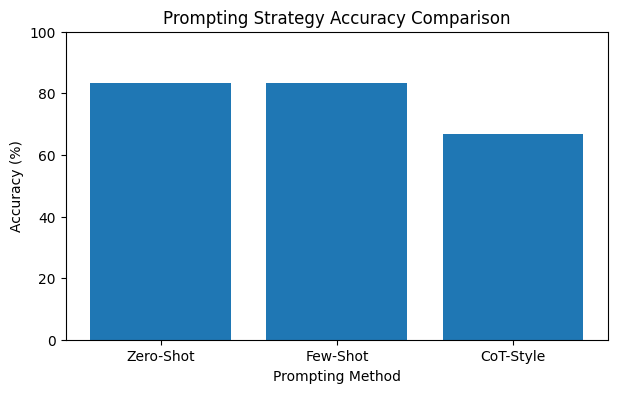

In [10]:
import matplotlib.pyplot as plt

methods = ["Zero-Shot", "Few-Shot", "CoT-Style"]
accuracies = [zero_acc, few_acc, cot_acc]

plt.figure(figsize=(7, 4))
plt.bar(methods, accuracies)
plt.title("Prompting Strategy Accuracy Comparison")
plt.xlabel("Prompting Method")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()

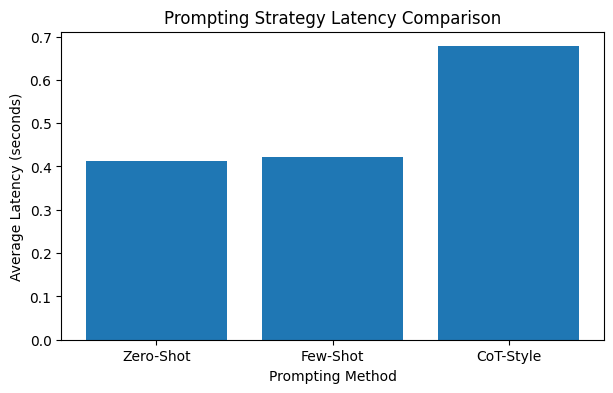

In [11]:
latencies = [zero_lat, few_lat, cot_lat]

plt.figure(figsize=(7, 4))
plt.bar(methods, latencies)
plt.title("Prompting Strategy Latency Comparison")
plt.xlabel("Prompting Method")
plt.ylabel("Average Latency (seconds)")
plt.show()

**Observation / Result**

**Observation:**

The same sentiment classification task was evaluated using Zero-Shot, Few-Shot and Chain-of-Thought-style prompting. Few-Shot prompting provided representative examples, while Zero-Shot prompting performed the task without demonstrations. The reasoning-oriented prompt instructed the model to think carefully but evaluated only the final label.

**Result:**

The accuracy, average output length and latency of the three prompting strategies were calculated and compared. The results show how prompt design can affect model performance, output length and inference time.